# Deseq2 

In [1]:
library(DESeq2)
library(tidyverse)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loading required package: SummarizedExperiment

Loading required package: M

Global variables!

In [2]:
padjThreshold <- 0.001
l2fcThreshold <- 1.5

Matrices and Coldata files

In [3]:
gfp_mtx <- "matrices_unionMockAuxResc_25/matrices/GFP_raw_counts.csv"
gfp_spl <- "GFP_raw_counts.csv"
gfp_cld <- "matrices_unionMockAuxResc_25/coldata/GFP_metadata.csv"

k27_mtx <- "matrices_unionMockAuxResc_25/matrices/K27_raw_counts.csv"
k27_spl <- "K27_raw_counts.csv"
k27_cld <- "matrices_unionMockAuxResc_25/coldata/K27_metadata.csv"

ub_mtx <- "matrices_unionMockAuxResc_25/matrices/UB_raw_counts.csv"
ub_spl <- "UB_raw_counts.csv"
ub_cld <- "matrices_unionMockAuxResc_25/coldata/UB_metadata.csv"

ad hoc deseq wrapper

In [4]:
mydeseq <- function(cMatrices,cMetadata, cNames, cPadjT, cL2fc, cMinCountSum = 4, cMalim = c(-10,10)){

        # Import files
        mx <- as.matrix(read.csv(cMatrices, row.names = 1))
        cd <- read.csv(cMetadata, row.names = 1)
        cd$condition <- factor(cd$condition)
        
        # include this to prevent errors due incorrect order of the tables
        if (all(rownames(cd)==colnames(mx))) {

            boxplot(log(mx+1), 
                    main = paste(cNames, "counts after filtering, threshold =",cMinCountSum),
                    ylab = "log(counts+1)",
                    xlab = "samples",
                    col = c("red","red","blue","blue","green","green")#,
                    #names = str_remove(colnames(mx), ".bam") |> str_remove("rep") #|> str_remove("^[a-z0-9]+_")
                   )
            
            #DESeq object init
            dds <- DESeqDataSetFromMatrix (countData = mx,
                                           colData = cd,
                                           design = ~ time
                                           )
            
            #DESeq statistical tests
            dds <- DESeq(dds)
            print(sizeFactors(dds))
            deseqResults <- results(dds)
            
            # MA plot
            plotMA(deseqResults, ylim=cMalim, alpha = cPadjT)
            abline(h = cL2fc, col = "red")
            abline(h = -cL2fc, col = "red")
            
            deseqResults$V1 <- rownames(deseqResults)
            
            deseqResults <- as.data.frame(deseqResults)
            deseqResults <- deseqResults |> dplyr::mutate(Significative = dplyr::case_when(
                (abs(log2FoldChange) > cL2fc & padj < cPadjT) ~ TRUE,
                #deseqResults$padj < cPadjT & deseqResults$log2FoldChange > cL2fc
                .default = FALSE))
            
             # Volcano plot
            print(ggplot(deseqResults ,aes(x= log2FoldChange, y = -log(padj), color = Significative)) + geom_point())
            
            dds <- estimateSizeFactors(dds)
            #print(sizeFactors(dds))
            normalizedCounts <- counts(dds, normalized=TRUE) |> as.data.frame()
            colnames(normalizedCounts) <- colnames(normalizedCounts) |> str_remove("\\.bam") |> toupper()
            normalizedCounts$V1 <- rownames(normalizedCounts)
            
            # add change directionality
            
            mx <- normalizedCounts
            mx$V1 <- NULL
            mx <- as.matrix(mx)
            
            
            # Write tables
            write.csv(deseqResults, paste0("./deseq2_mockAuxResc_results_36/",cNames,"_deseq_results.csv"), quote = F, row.names = F)
            write.csv(normalizedCounts, paste0("./deseq2_mockAuxResc_results_36/",cNames,"_norm_counts.csv"), quote = F, row.names = F)
            
            # summary of results
            summary(deseqResults)
            print(paste("Significative increased signal:", sum(deseqResults$padj < cPadjT & deseqResults$log2FoldChange > cL2fc ,na.rm = TRUE)))
            print(paste("Significative decreased signal:",sum(deseqResults$padj < cPadjT & deseqResults$log2FoldChange < -cL2fc ,na.rm = TRUE)))
            print(paste0("log2(FoldChange) threshold: +/-",cL2fc))
            print(paste0("Adjusted P-value threshold: ",cPadjT))
            
        } else { 
            print("matrix colnames doesn't match rownames of metadata, must be ordered equally")
            print("metadata rownames:")
            print(rownames(cd))
            print("matrix colnames:")
            print(colnames(mx))
        }
}

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



       Auxin_GFP.1        Auxin_GFP.2         Mock_GFP.1         Mock_GFP.2 
         0.5987346          0.4902872          2.2176889          2.3126952 
SimpleRescue_GFP.1 SimpleRescue_GFP.2 
         0.8874027          1.0980101 


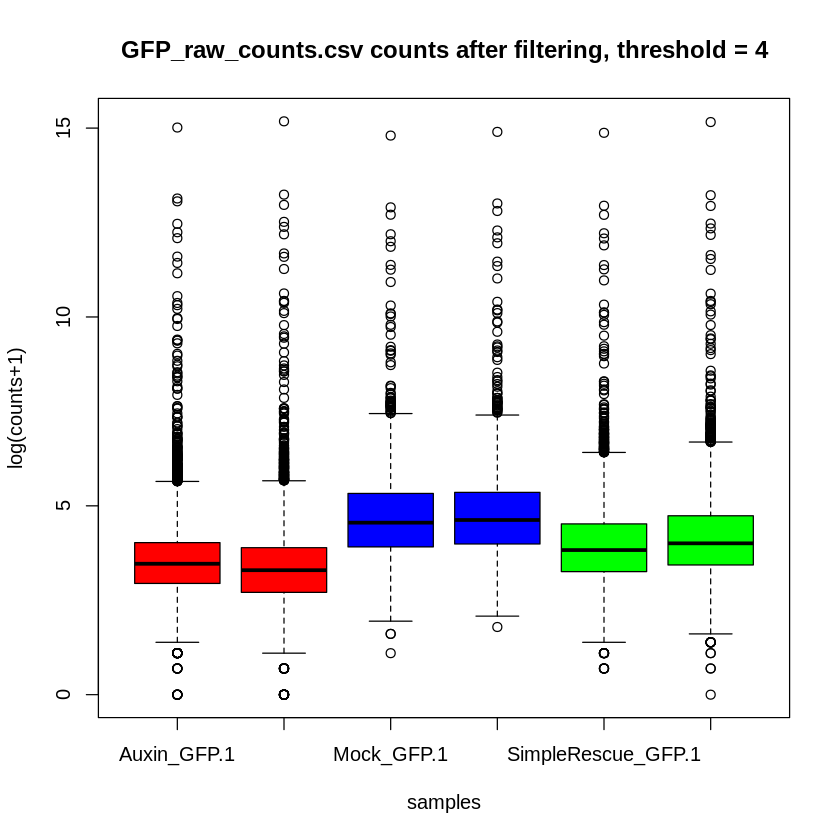

Warning message:
“Removed 249 rows containing missing values (`geom_point()`).”


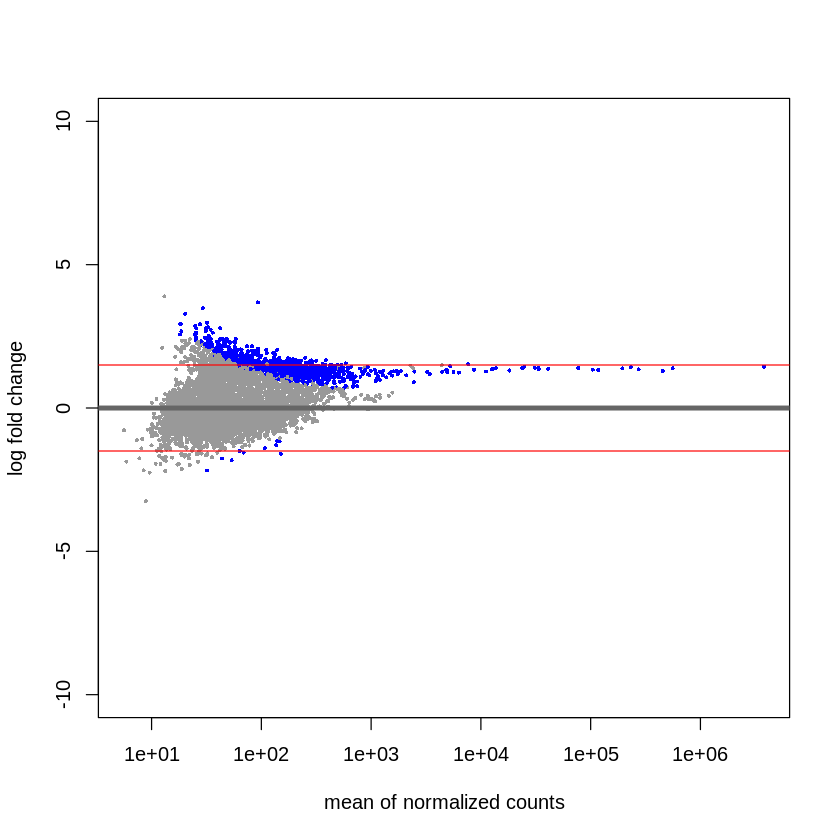

[1] "Significative increased signal: 357"
[1] "Significative decreased signal: 6"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


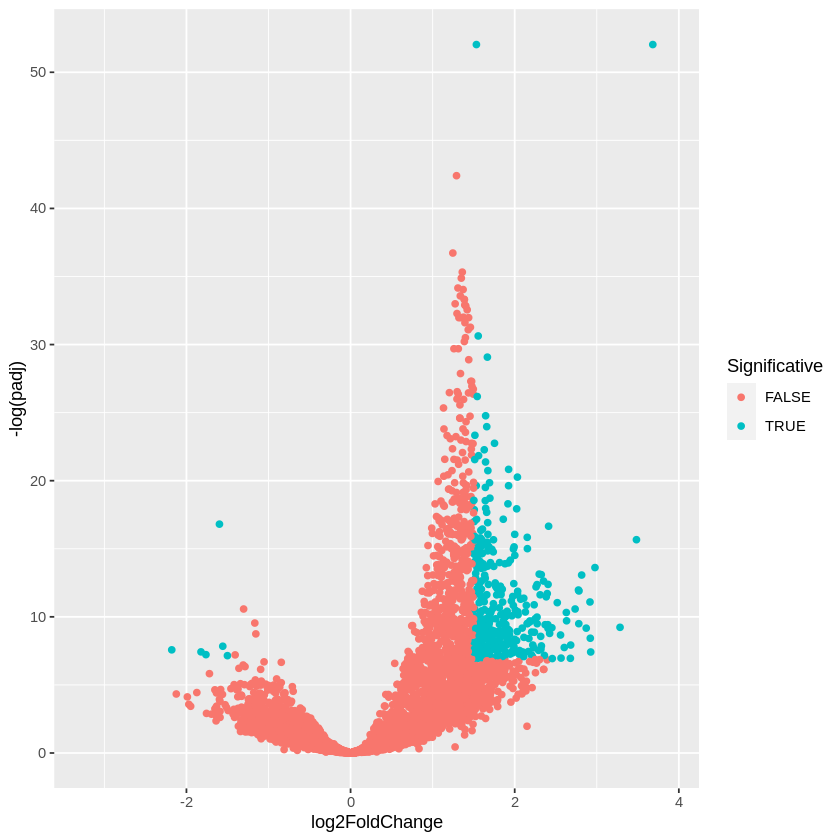

In [5]:
mydeseq(gfp_mtx,gfp_cld,gfp_spl,padjThreshold,l2fcThreshold)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



       Auxin_K27.1        Auxin_K27.2         Mock_K27.1         Mock_K27.2 
         0.2942696          0.4642607          1.3417838          2.0441153 
SimpleRescue_K27.1 SimpleRescue_K27.2 
         1.6056862          1.3652575 


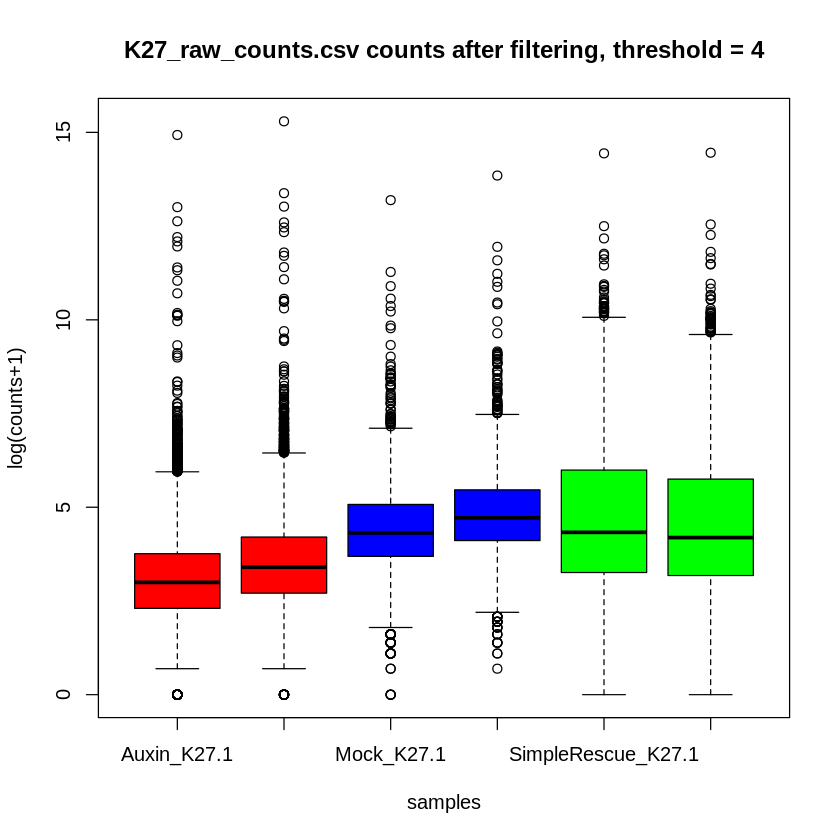

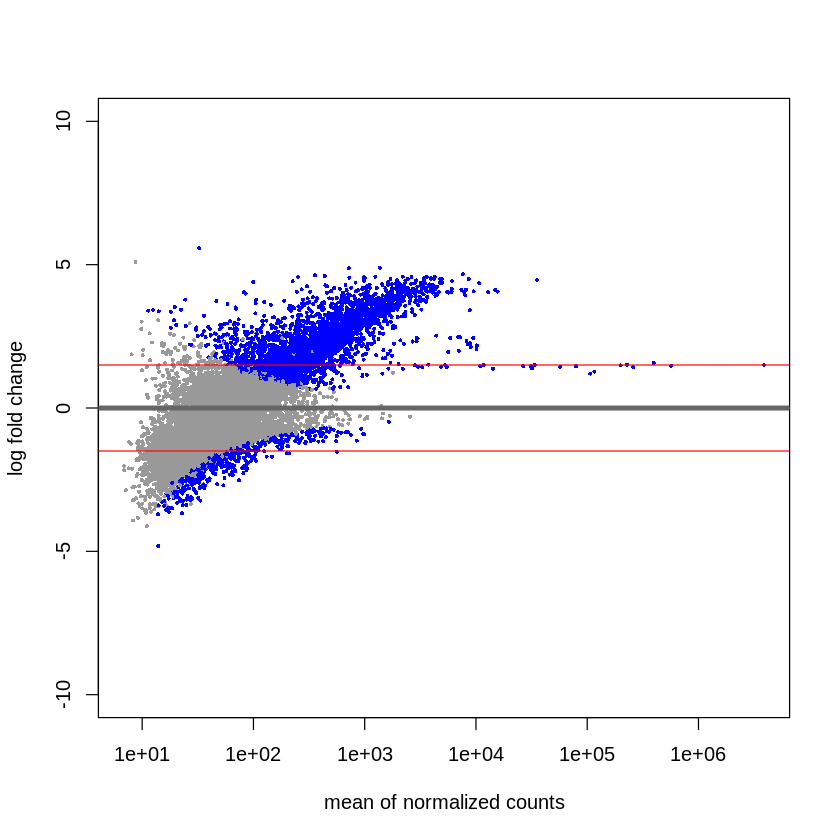

[1] "Significative increased signal: 2559"
[1] "Significative decreased signal: 316"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


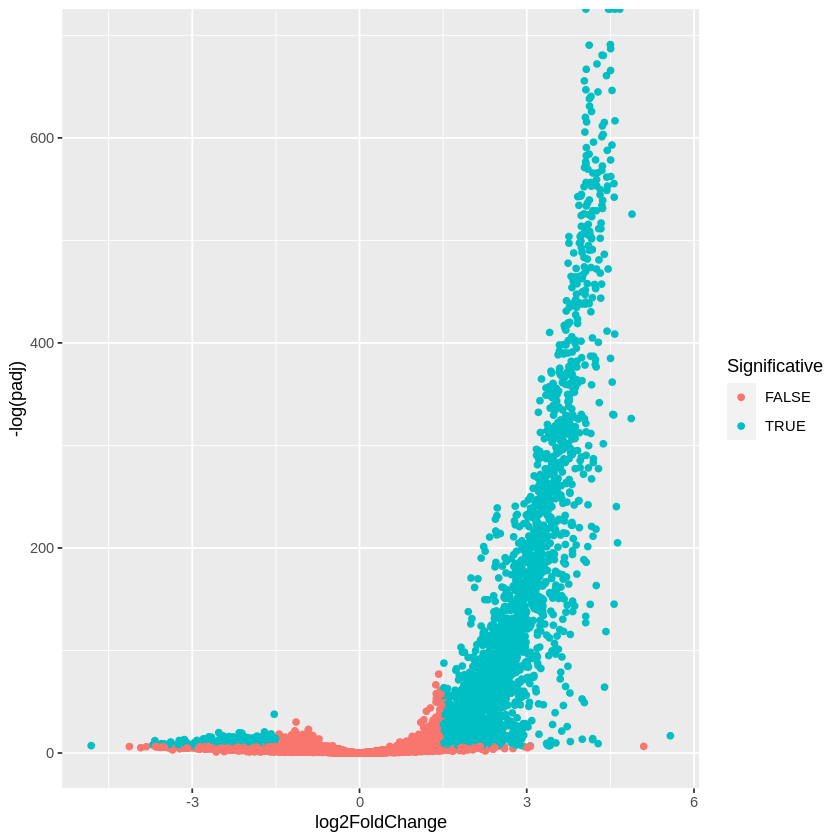

In [6]:
mydeseq(k27_mtx,k27_cld,k27_spl,padjThreshold,l2fcThreshold)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



        Auxin_UB.1         Auxin_UB.2          Mock_UB.1          Mock_UB.2 
         0.9335009          1.5926839          0.9130270          1.0522200 
RescateSimple_UB.1 RescateSimple_UB.2 
         0.7667766          0.9652392 


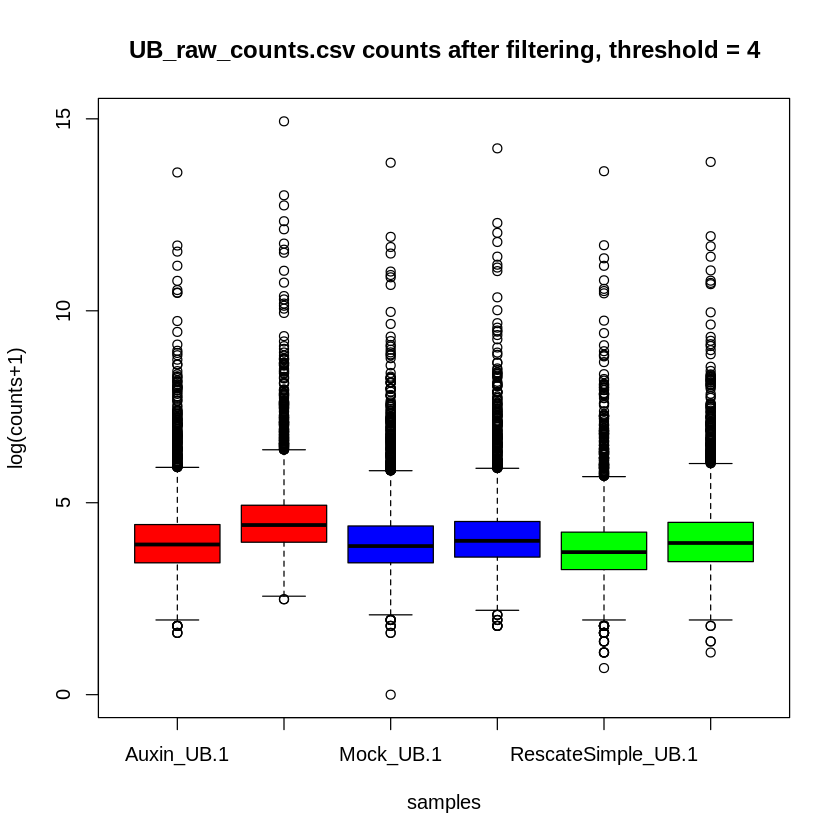

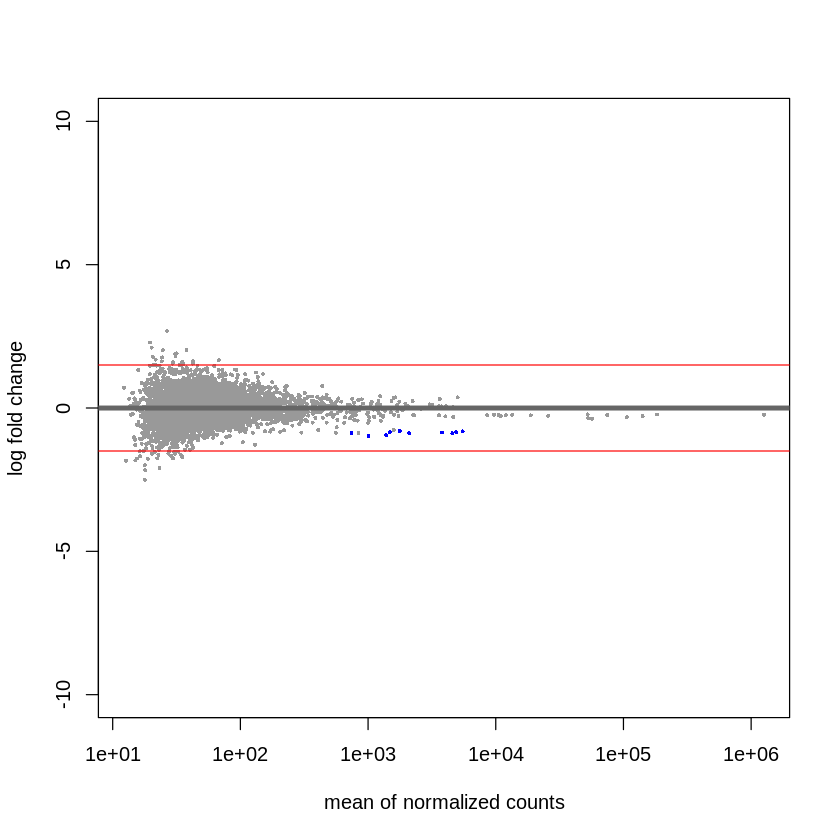

[1] "Significative increased signal: 0"
[1] "Significative decreased signal: 0"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


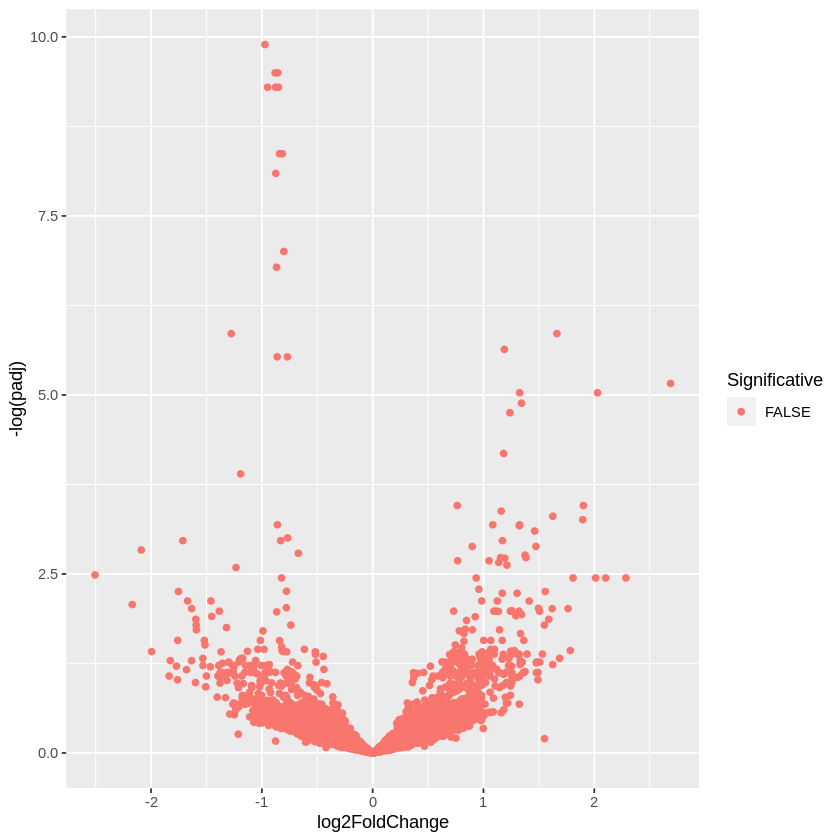

In [7]:
mydeseq(ub_mtx,ub_cld,ub_spl,padjThreshold,l2fcThreshold)